        Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                0.0     1.0       1.0        1.0  24.0     0.0     0.0   
...              ...     ...       ...        ...   ...     ...     ...   
253675           0.0     1.0       1.0        1.0  45.0     0.0     0.0   
253676           2.0     1.0       1.0        1.0  18.0     0.0     0.0   
253677           0.0     0.0       0.0        1.0  28.0     0.0     0.0   
253678           0.0     1.0       0.0        1.0  23.0     0.0     0.0   
253679           2.0     1.0       1.0        1.0  25.0     0.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                        

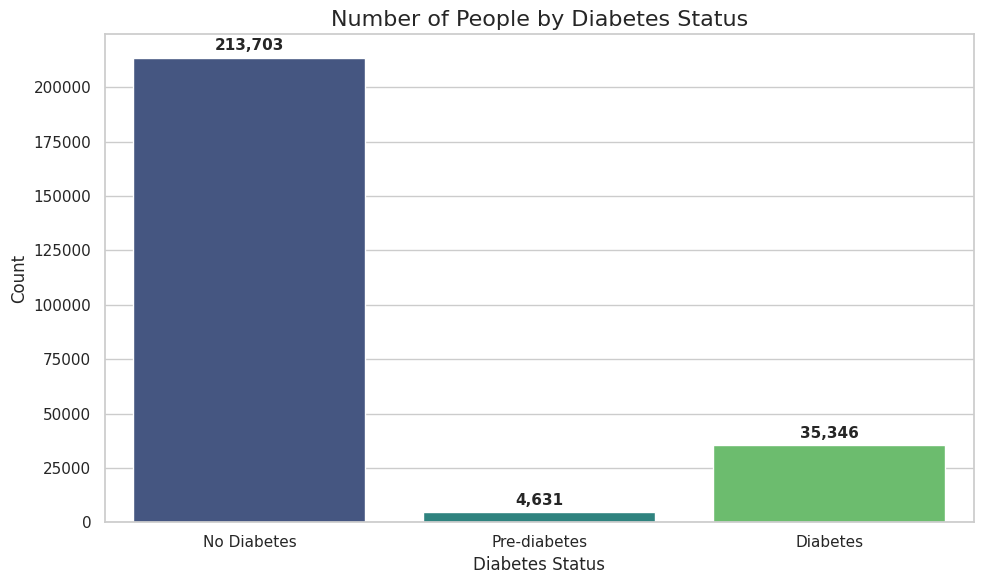

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
###########################what Data Contain #################################################
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
print(df)
diabetes_map = {0.0: 'No Diabetes', 1.0: 'Pre-diabetes', 2.0: 'Diabetes'}
df['Diabetes_Status'] = df['Diabetes_012'].map(diabetes_map)
status_counts = df['Diabetes_Status'].value_counts().reindex(['No Diabetes', 'Pre-diabetes', 'Diabetes'])
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the bar chart
plot = sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    hue=status_counts.index,  # Assign x to hue
    palette='viridis',
    legend=False              # Hide the extra legend box
)

# Add labels and title
plt.title('Number of People by Diabetes Status', fontsize=16)
plt.xlabel('Diabetes Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add the count numbers on top of each bar for better readability
for i, count in enumerate(status_counts.values):
    plt.text(i, count + 2000, f'{int(count):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('diabetes_bar_chart.png')
plt.show()

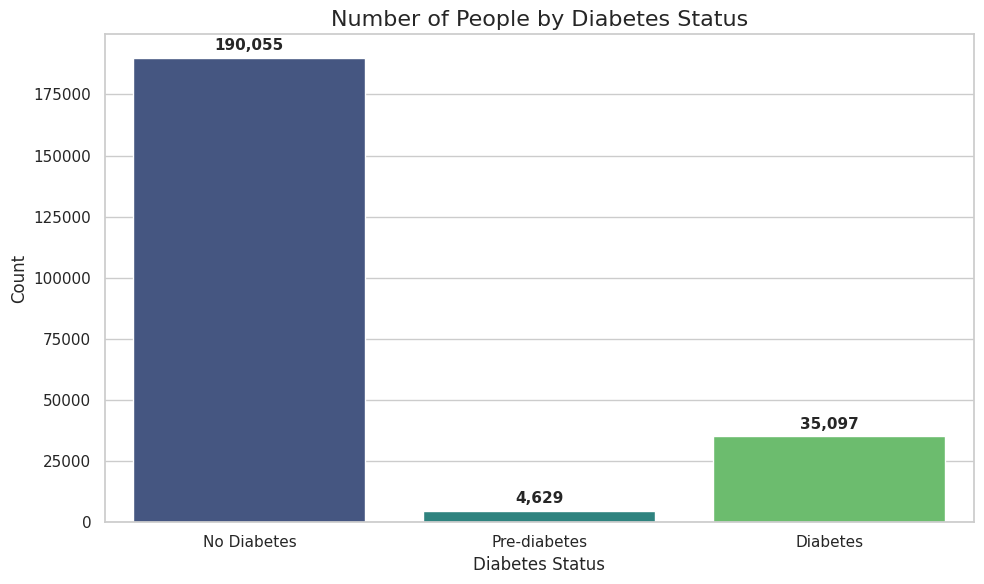

In [129]:
#cleaning Data

df.dropna(inplace= True)
df.drop_duplicates(inplace = True)
status_counts = df['Diabetes_Status'].value_counts().reindex(['No Diabetes', 'Pre-diabetes', 'Diabetes'])
## Data does not contain empty cell
##############################plot after remove duplicates####################################
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the bar chart
plot = sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    hue=status_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Number of People by Diabetes Status', fontsize=16)
plt.xlabel('Diabetes Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

for i, count in enumerate(status_counts.values):
    plt.text(i, count + 2000, f'{int(count):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('diabetes_after_re_dublicates.png')
plt.show()

In [130]:
x = df.drop(columns=['Diabetes_012','Diabetes_Status'])
y = df['Diabetes_012']
df=df.drop(columns=['Diabetes_Status'])
X_train_val, X_test, y_train_val, y_test = train_test_split(
    x, y,
    test_size=0.20,      # 20% for testing
    random_state=42,     # Fixed seed for reproducibility
    stratify=y         # Maintain class proportions
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.125,     # 12.5% of the 80% is 10% of the original
    random_state=42,
    stratify=y_train_val
)

def print_distribution(y_set, name):
    counts = y_set.value_counts().sort_index()
    percentages = y_set.value_counts(normalize=True).sort_index() * 100
    labels = {0.0: 'No Diabetes', 1.0: 'Pre-diabetes', 2.0: 'Diabetes'}

    print(f"--- {name} Set ---")
    for val in [0.0, 1.0, 2.0]:
        print(f"{labels[val]}: {int(counts[val])} samples ({percentages[val]:.2f}%)")
    print("-" * 30)

print_distribution(y_train, "Training (70%)")
print_distribution(y_val, "Validation (10%)")
print_distribution(y_test, "Testing (20%)")


--- Training (70%) Set ---
No Diabetes: 133038 samples (82.71%)
Pre-diabetes: 3240 samples (2.01%)
Diabetes: 24568 samples (15.27%)
------------------------------
--- Validation (10%) Set ---
No Diabetes: 19005 samples (82.71%)
Pre-diabetes: 463 samples (2.01%)
Diabetes: 3510 samples (15.28%)
------------------------------
--- Testing (20%) Set ---
No Diabetes: 38012 samples (82.71%)
Pre-diabetes: 926 samples (2.01%)
Diabetes: 7019 samples (15.27%)
------------------------------


In [131]:
### scaling the data
scaler = StandardScaler()

features_to_scale = [
    "BMI",
    "MentHlth",
    "PhysHlth",
    "GenHlth",
    "Age",
    "Education",
    "Income"
]

X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_val[features_to_scale] = scaler.transform(X_val[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])
print(X_train)
print(X_val)

        HighBP  HighChol  CholCheck       BMI  Smoker  Stroke  \
107646     0.0       1.0        1.0 -0.837749     0.0     0.0   
183234     1.0       1.0        1.0  0.779355     1.0     0.0   
133308     1.0       1.0        1.0  1.367392     0.0     0.0   
116763     1.0       1.0        1.0 -0.396720     1.0     0.0   
98863      0.0       0.0        1.0  1.220383     1.0     0.0   
...        ...       ...        ...       ...     ...     ...   
29652      0.0       0.0        1.0  1.073373     1.0     0.0   
7644       0.0       1.0        1.0 -0.543730     0.0     0.0   
191656     0.0       1.0        1.0 -0.249711     1.0     0.0   
242217     1.0       1.0        1.0 -0.837749     0.0     0.0   
196847     0.0       0.0        1.0 -0.837749     0.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  ...  \
107646                   0.0           1.0     1.0      1.0  ...   
183234                   0.0           1.0     1.0      1.0  ...   
133308         

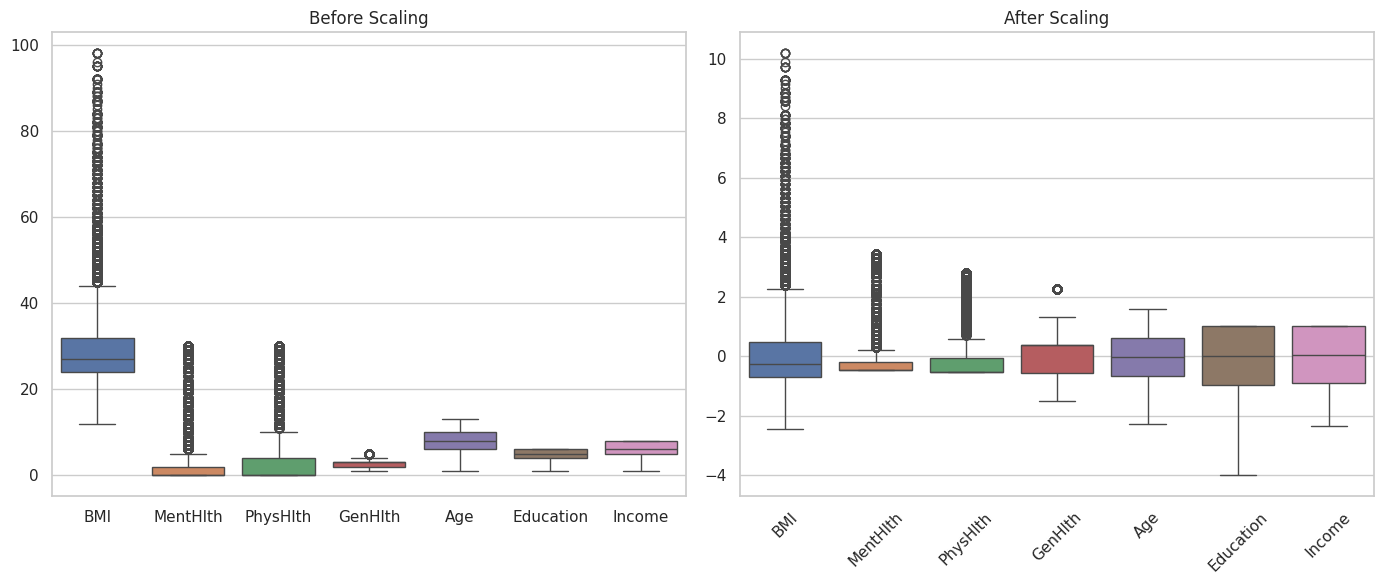

In [132]:
### plot before and after scaling ###########
fig, ax = plt.subplots(1,2, figsize=(14,6))

sns.boxplot(data=df[features_to_scale], ax=ax[0])
ax[0].set_title("Before Scaling")

sns.boxplot(data=X_train[features_to_scale], ax=ax[1])
ax[1].set_title("After Scaling")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

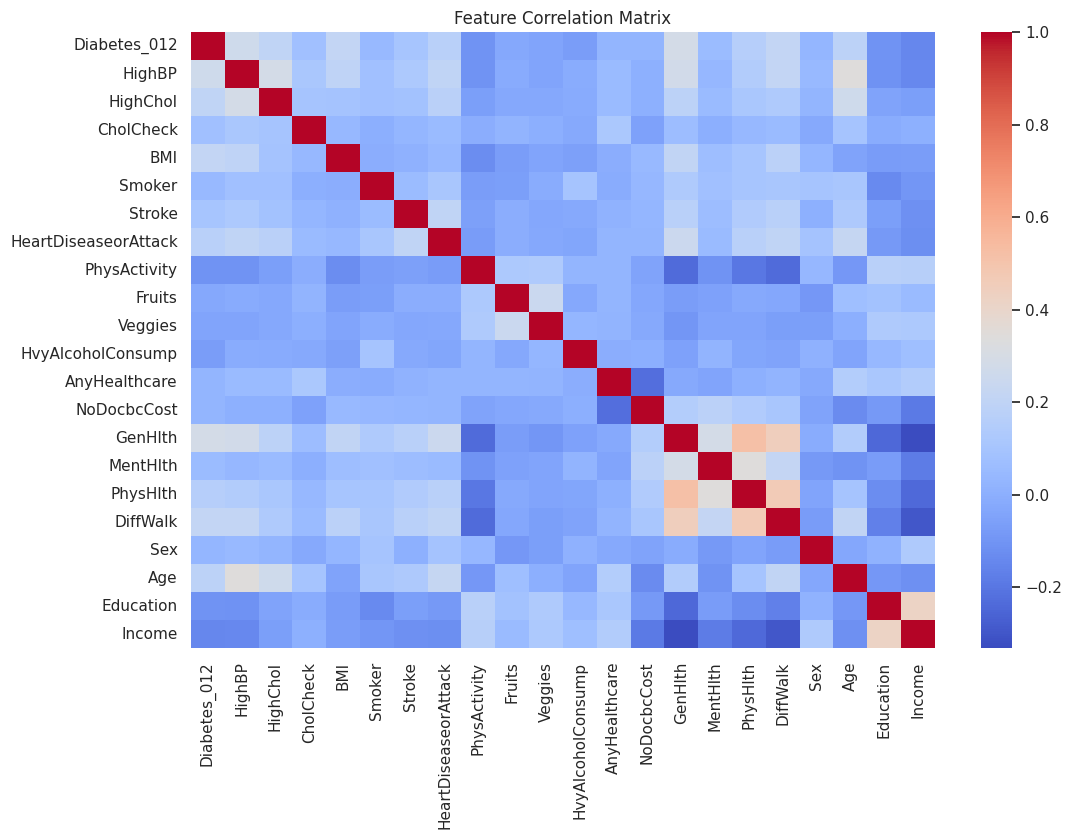

Diabetes_012            1.000000
GenHlth                 0.284881
HighBP                  0.261976
BMI                     0.212027
DiffWalk                0.210638
HighChol                0.203327
Age                     0.184642
HeartDiseaseorAttack    0.170816
PhysHlth                0.160485
Stroke                  0.100276
CholCheck               0.075701
MentHlth                0.057698
Smoker                  0.046774
Sex                     0.032243
AnyHealthcare           0.024911
NoDocbcCost             0.023568
Fruits                 -0.025462
Veggies                -0.043446
HvyAlcoholConsump      -0.067164
PhysActivity           -0.103408
Education              -0.107742
Income                 -0.147102
Name: Diabetes_012, dtype: float64


In [133]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

correlation_matrix = df.corr()
diabetes_correlation = correlation_matrix["Diabetes_012"]
sorted_correlation = diabetes_correlation.sort_values(ascending=False)
print(sorted_correlation)


In [134]:
selector = SelectKBest(score_func=chi2, k=10)
X_new = selector.fit_transform(x, y)
scores = selector.scores_

feature_score_pairs = list(zip(x.columns, scores))


feature_score_pairs.sort(key=lambda x: x[1], reverse=True)


print(f"{'Feature':<22} | {'Chi-Squared Score'}")
print("-" * 40)
for feature, score in feature_score_pairs:
    print(f"{feature:<22} | {score:.4f}")

Feature                | Chi-Squared Score
----------------------------------------
PhysHlth               | 103705.8134
BMI                    | 16667.0062
MentHlth               | 13499.0566
Age                    | 9400.4089
HighBP                 | 8633.5628
DiffWalk               | 8310.2805
GenHlth                | 8142.6027
HeartDiseaseorAttack   | 6015.6619
HighChol               | 5381.9855
Income                 | 3748.2547
Stroke                 | 2212.0608
HvyAlcoholConsump      | 973.6770
PhysActivity           | 656.1876
Education              | 537.0689
Smoker                 | 268.9241
NoDocbcCost            | 163.1384
Sex                    | 136.9989
Veggies                | 89.5549
Fruits                 | 57.6667
CholCheck              | 54.1557
AnyHealthcare          | 7.8835


HighBP 0.03816826835257054
HighChol 0.02542726668857662
CholCheck 0.0038215510457111387
BMI 0.18560700084358128
Smoker 0.03382151335574722
Stroke 0.012371509028770308
HeartDiseaseorAttack 0.016782516530830786
PhysActivity 0.027410919859978972
Fruits 0.034085605388312304
Veggies 0.027787535516456973
HvyAlcoholConsump 0.007606272473031681
AnyHealthcare 0.009002693995545223
NoDocbcCost 0.01559297509933992
GenHlth 0.06472212717127417
MentHlth 0.0645098404887277
PhysHlth 0.08513006823398883
DiffWalk 0.022369291689363253
Sex 0.027244904951742942
Age 0.12250111599989236
Education 0.07377919509341169
Income 0.10225782819314604


<Axes: xlabel='Feature'>

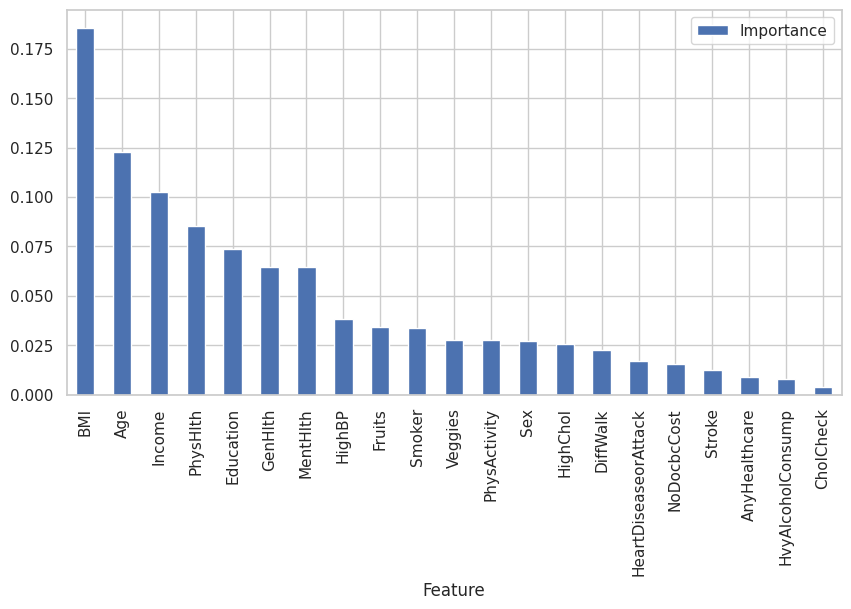

In [135]:
model = RandomForestClassifier()
model.fit(x, y)

importance = model.feature_importances_

for feature, score in zip(x.columns, importance):
    print(feature, score)

importance_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
})

importance_df.sort_values("Importance", ascending=False).plot.bar(
    x="Feature", y="Importance", figsize=(10,5)
)

In [136]:

# List of alpha values to try
alphas = [0.001, 0.01, 0.1, 1]

best_alpha = None
best_score = -float('inf')

# Hyperparameter tuning using validation set
for alpha in alphas:
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)  # use only training set
    score = model.score(X_val, y_val)  # evaluate on validation set
    if score > best_score:
        best_score = score
        best_alpha = alpha

print("Best alpha:", best_alpha)

# Train final Lasso with best alpha on the training set
final_model = Lasso(alpha=best_alpha)
final_model.fit(X_train, y_train)

# Create a DataFrame with feature weights
weights_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': final_model.coef_
})

weights_df['Magnitude'] = weights_df['Weight'].abs()
weights_df = weights_df.sort_values(by='Magnitude', ascending=False)

print(weights_df[['Feature', 'Weight']])

Best alpha: 0.001
                 Feature    Weight
0                 HighBP  0.160669
1               HighChol  0.129010
6   HeartDiseaseorAttack  0.112157
13               GenHlth  0.109524
3                    BMI  0.098206
10     HvyAlcoholConsump -0.091847
2              CholCheck  0.070230
16              DiffWalk  0.069522
18                   Age  0.056391
5                 Stroke  0.049336
17                   Sex  0.038711
20                Income -0.026111
11         AnyHealthcare  0.014147
4                 Smoker -0.010089
7           PhysActivity -0.007717
14              MentHlth -0.006503
19             Education -0.004713
12           NoDocbcCost -0.001957
8                 Fruits -0.000155
9                Veggies -0.000000
15              PhysHlth -0.000000


In [137]:
selected_features = weights_df[weights_df['Magnitude'] > 0.01]['Feature']

X_train = X_train[selected_features]
X_val = X_val[selected_features]
X_test = X_test[selected_features]

print("Selected Features:", list(selected_features))

Selected Features: ['HighBP', 'HighChol', 'HeartDiseaseorAttack', 'GenHlth', 'BMI', 'HvyAlcoholConsump', 'CholCheck', 'DiffWalk', 'Age', 'Stroke', 'Sex', 'Income', 'AnyHealthcare', 'Smoker']


In [138]:
## Random oversampling
ros = RandomOverSampler(random_state=42)

X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print("Before oversampling:")
print(y_train.value_counts())
print("\nAfter oversampling:")
print(y_train_over.value_counts())

Before oversampling:
Diabetes_012
0.0    133038
2.0     24568
1.0      3240
Name: count, dtype: int64

After oversampling:
Diabetes_012
0.0    133038
2.0    133038
1.0    133038
Name: count, dtype: int64


In [139]:
# Smote sampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Diabetes_012
0.0    133038
2.0     24568
1.0      3240
Name: count, dtype: int64

After SMOTE:
Diabetes_012
0.0    133038
2.0    133038
1.0    133038
Name: count, dtype: int64


In [140]:

rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Before undersampling:")
print(y_train.value_counts())

print("\nAfter undersampling:")
print(y_train_under.value_counts())

Before undersampling:
Diabetes_012
0.0    133038
2.0     24568
1.0      3240
Name: count, dtype: int64

After undersampling:
Diabetes_012
0.0    3240
1.0    3240
2.0    3240
Name: count, dtype: int64


In [141]:
#### class weights technique for unbalanced data please try it muhnad

In [142]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

#softmax Regression (imbalanced Data)
print("BASELINE SOFTMAX REGRESSION (Imbalanced Data)")


C_values = [0.001, 0.01, 0.1, 1, 10, 100]
best_C = None
best_val_acc = 0

for C in C_values:
    model = LogisticRegression(solver='lbfgs', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val))
    print(f"C={C}: Validation Accuracy = {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C

print(f"\nBest C: {best_C}")

baseline_model = LogisticRegression(solver='lbfgs', C=best_C, max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(classification_report(y_test, y_pred_baseline))

# softmax Regression with SMOTE
print("SOFTMAX REGRESSION WITH SMOTE (Balanced Data)")


best_C_smote = None
best_val_acc_smote = 0

for C in C_values:
    model = LogisticRegression(solver='lbfgs', C=C, max_iter=1000, random_state=42)
    model.fit(X_train_smote, y_train_smote)
    val_acc = accuracy_score(y_val, model.predict(X_val))
    print(f"C={C}: Validation Accuracy = {val_acc:.4f}")
    if val_acc > best_val_acc_smote:
        best_val_acc_smote = val_acc
        best_C_smote = C

print(f"\nBest C: {best_C_smote}")

smote_model = LogisticRegression(solver='lbfgs', C=best_C_smote, max_iter=1000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print(classification_report(y_test, y_pred_smote))


BASELINE SOFTMAX REGRESSION (Imbalanced Data)
C=0.001: Validation Accuracy = 0.8324
C=0.01: Validation Accuracy = 0.8330
C=0.1: Validation Accuracy = 0.8330
C=1: Validation Accuracy = 0.8330
C=10: Validation Accuracy = 0.8331
C=100: Validation Accuracy = 0.8330

Best C: 10

Test Accuracy: 0.8331
              precision    recall  f1-score   support

         0.0       0.85      0.98      0.91     38012
         1.0       0.00      0.00      0.00       926
         2.0       0.55      0.17      0.26      7019

    accuracy                           0.83     45957
   macro avg       0.46      0.38      0.39     45957
weighted avg       0.78      0.83      0.79     45957

SOFTMAX REGRESSION WITH SMOTE (Balanced Data)
C=0.001: Validation Accuracy = 0.6257
C=0.01: Validation Accuracy = 0.6231
C=0.1: Validation Accuracy = 0.6229
C=1: Validation Accuracy = 0.6228
C=10: Validation Accuracy = 0.6229
C=100: Validation Accuracy = 0.6228

Best C: 0.001

Test Accuracy: 0.6285
              precisio

In [146]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from imblearn.combine import SMOTEENN
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Expanded C grid over several orders of magnitude
C_values = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4]


def tune_and_evaluate(X_tr, y_tr, label, class_weight=None):
    best_C, best_val_f1 = None, 0
    for C in C_values:
        # Multiclass softmax-style logistic regression (lbfgs with 3 classes)
        m = LogisticRegression(
            solver='lbfgs',
            C=C,
            max_iter=5000,
            random_state=42,
            class_weight=class_weight
        )
        m.fit(X_tr, y_tr)
        val_f1 = f1_score(y_val, m.predict(X_val), average='macro')
        if val_f1 > best_val_f1:
            best_val_f1, best_C = val_f1, C

    final = LogisticRegression(
        solver='lbfgs',
        C=best_C,
        max_iter=5000,
        random_state=42,
        class_weight=class_weight
    )
    final.fit(X_tr, y_tr)
    y_pred = final.predict(X_test)

    print(f'\n{"="*55}')
    print(f'  {label}')
    print(f'{"="*55}')
    print(f'Best C: {best_C}')
    print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f'Test Macro F1 : {f1_score(y_test, y_pred, average="macro"):.4f}')
    print(classification_report(y_test, y_pred,
          target_names=['No Diabetes', 'Pre-diabetes', 'Diabetes']))

    return {
        'Strategy'        : label,
        'Best C'          : best_C,
        'Accuracy'        : round(accuracy_score(y_test, y_pred), 4),
        'Macro F1'        : round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 No-Diabetes'  : round(f1_score(y_test, y_pred, average=None)[0], 4),
        'F1 Pre-diabetes' : round(f1_score(y_test, y_pred, average=None)[1], 4),
        'F1 Diabetes'     : round(f1_score(y_test, y_pred, average=None)[2], 4),
    }

results = []

In [147]:
res = tune_and_evaluate(X_train, y_train,
                        label='1. Baseline (No Balancing)')
results.append(res)


  1. Baseline (No Balancing)
Best C: 10
Test Accuracy : 0.8331
Test Macro F1 : 0.3886
              precision    recall  f1-score   support

 No Diabetes       0.85      0.98      0.91     38012
Pre-diabetes       0.00      0.00      0.00       926
    Diabetes       0.55      0.17      0.26      7019

    accuracy                           0.83     45957
   macro avg       0.46      0.38      0.39     45957
weighted avg       0.78      0.83      0.79     45957



In [148]:
res = tune_and_evaluate(X_train_over, y_train_over,
                        label='2. Random Oversampling')
results.append(res)


  2. Random Oversampling
Best C: 0.001
Test Accuracy : 0.6340
Test Macro F1 : 0.4267
              precision    recall  f1-score   support

 No Diabetes       0.94      0.65      0.77     38012
Pre-diabetes       0.03      0.28      0.06       926
    Diabetes       0.37      0.60      0.45      7019

    accuracy                           0.63     45957
   macro avg       0.45      0.51      0.43     45957
weighted avg       0.84      0.63      0.71     45957



In [149]:
res = tune_and_evaluate(X_train_smote, y_train_smote,
                        label='3. SMOTE')
results.append(res)


  3. SMOTE
Best C: 0.0001
Test Accuracy : 0.6384
Test Macro F1 : 0.4276
              precision    recall  f1-score   support

 No Diabetes       0.94      0.66      0.77     38012
Pre-diabetes       0.03      0.28      0.06       926
    Diabetes       0.37      0.59      0.45      7019

    accuracy                           0.64     45957
   macro avg       0.45      0.51      0.43     45957
weighted avg       0.84      0.64      0.71     45957



In [150]:
res = tune_and_evaluate(X_train_under, y_train_under,
                        label='4. Random Undersampling')
results.append(res)


  4. Random Undersampling
Best C: 0.0001
Test Accuracy : 0.6893
Test Macro F1 : 0.4323
              precision    recall  f1-score   support

 No Diabetes       0.93      0.71      0.80     38012
Pre-diabetes       0.03      0.10      0.04       926
    Diabetes       0.34      0.65      0.45      7019

    accuracy                           0.69     45957
   macro avg       0.43      0.49      0.43     45957
weighted avg       0.82      0.69      0.73     45957



In [151]:
from imblearn.combine import SMOTEENN

smoteenn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train, y_train)

print('After SMOTEENN:')
print(pd.Series(y_train_smoteenn).value_counts())

res = tune_and_evaluate(X_train_smoteenn, y_train_smoteenn,
                        label='5. SMOTEENN')
results.append(res)

After SMOTEENN:
Diabetes_012
1.0    114688
2.0     85189
0.0     83512
Name: count, dtype: int64

  5. SMOTEENN
Best C: 0.1
Test Accuracy : 0.5015
Test Macro F1 : 0.3774
              precision    recall  f1-score   support

 No Diabetes       0.96      0.52      0.68     38012
Pre-diabetes       0.03      0.60      0.05       926
    Diabetes       0.44      0.37      0.40      7019

    accuracy                           0.50     45957
   macro avg       0.48      0.50      0.38     45957
weighted avg       0.86      0.50      0.62     45957



In [152]:
res = tune_and_evaluate(X_train, y_train,
                        label='6. Class Weights (balanced)',
                        class_weight='balanced')
results.append(res)


  6. Class Weights (balanced)
Best C: 0.0001
Test Accuracy : 0.6501
Test Macro F1 : 0.4310
              precision    recall  f1-score   support

 No Diabetes       0.94      0.67      0.78     38012
Pre-diabetes       0.03      0.26      0.06       926
    Diabetes       0.36      0.60      0.45      7019

    accuracy                           0.65     45957
   macro avg       0.45      0.51      0.43     45957
weighted avg       0.83      0.65      0.72     45957




COMPARISON TABLE (sorted by Macro F1)
                   Strategy  Best C  Accuracy  Macro F1  F1 No-Diabetes  F1 Pre-diabetes  F1 Diabetes
    4. Random Undersampling  0.0001    0.6893    0.4323          0.8040           0.0415       0.4514
6. Class Weights (balanced)  0.0001    0.6501    0.4310          0.7807           0.0581       0.4542
                   3. SMOTE  0.0001    0.6384    0.4276          0.7734           0.0578       0.4515
     2. Random Oversampling  0.0010    0.6340    0.4267          0.7690           0.0568       0.4543
 1. Baseline (No Balancing) 10.0000    0.8331    0.3886          0.9071           0.0000       0.2587
                5. SMOTEENN  0.1000    0.5015    0.3774          0.6782           0.0544       0.3996

>>> Best strategy: 4. Random Undersampling


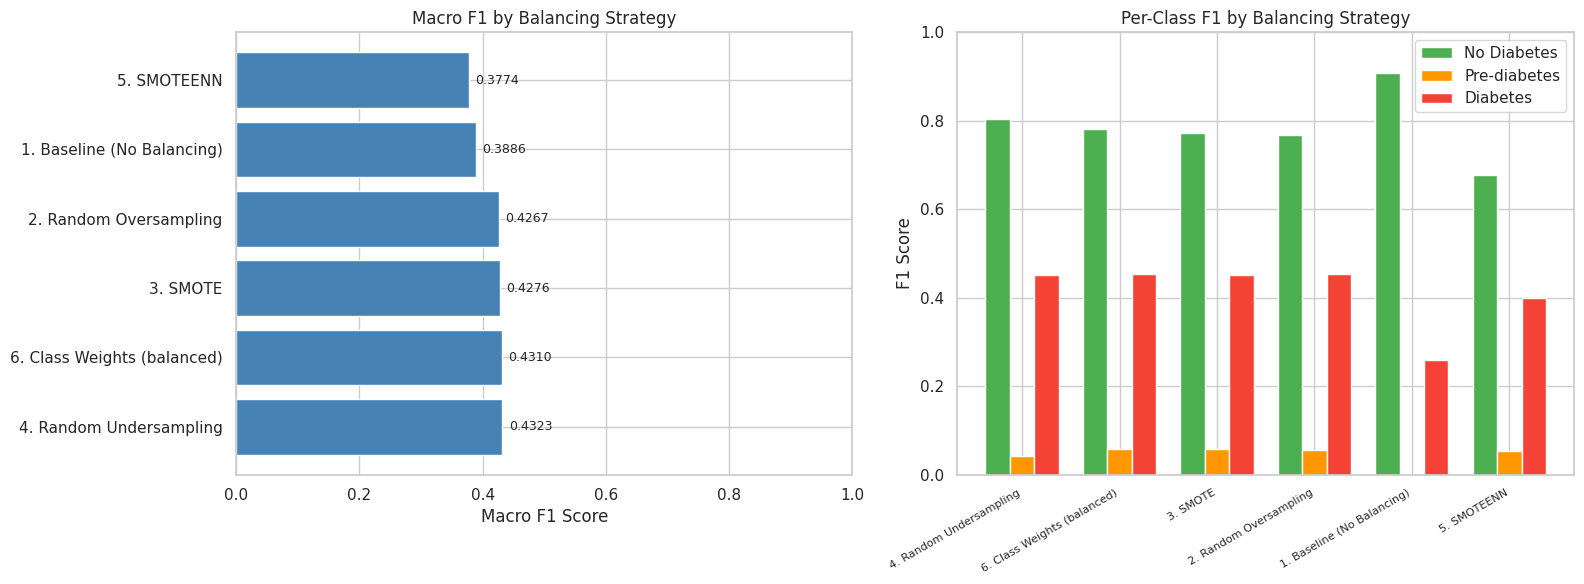

In [153]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('\n' + '='*70)
print('COMPARISON TABLE (sorted by Macro F1)')
print('='*70)
print(comparison_df.to_string(index=False))
print('\n>>> Best strategy:', comparison_df.iloc[0]['Strategy'])

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Macro F1
axes[0].barh(comparison_df['Strategy'], comparison_df['Macro F1'],
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Macro F1 Score')
axes[0].set_title('Macro F1 by Balancing Strategy')
axes[0].set_xlim(0, 1)
for i, v in enumerate(comparison_df['Macro F1']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

# Per-class F1
x = range(len(comparison_df))
width = 0.25
axes[1].bar([i - width for i in x], comparison_df['F1 No-Diabetes'],
            width, label='No Diabetes', color='#4CAF50')
axes[1].bar(x, comparison_df['F1 Pre-diabetes'],
            width, label='Pre-diabetes', color='#FF9800')
axes[1].bar([i + width for i in x], comparison_df['F1 Diabetes'],
            width, label='Diabetes', color='#F44336')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(comparison_df['Strategy'], rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-Class F1 by Balancing Strategy')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()